In [ ]:
#importing necessary libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [ ]:
#loading CIFAR-10 dataset which contains 60,000 images in 10 classes
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

In [ ]:
#normalizing pixel values (0-255 -> 0-1) for better performance
x_train, x_test = x_train/255.0, x_test/255.0

In [ ]:
#building CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#compile model
model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
#train model
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 45ms/step - accuracy: 0.4505 - loss: 1.5058 - val_accuracy: 0.5588 - val_loss: 1.2400
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.5995 - loss: 1.1387 - val_accuracy: 0.6148 - val_loss: 1.0962
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6513 - loss: 0.9919 - val_accuracy: 0.6610 - val_loss: 0.9769
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.6842 - loss: 0.8930 - val_accuracy: 0.6807 - val_loss: 0.9079
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.7109 - loss: 0.8264 - val_accuracy: 0.6502 - val_loss: 1.0572
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 46ms/step - accuracy: 0.7286 - loss: 0.7725 - val_accuracy: 0.6897 - val_loss: 0.9059
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 48ms/step - accuracy: 0.7446 - loss: 0.7262 - val_accuracy: 0.7090 - val_loss: 0.8583
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 52ms/step - accuracy: 0.7587 -

In [ ]:
#evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7063 - loss: 0.8814
Test Accuracy: 0.7063000202178955


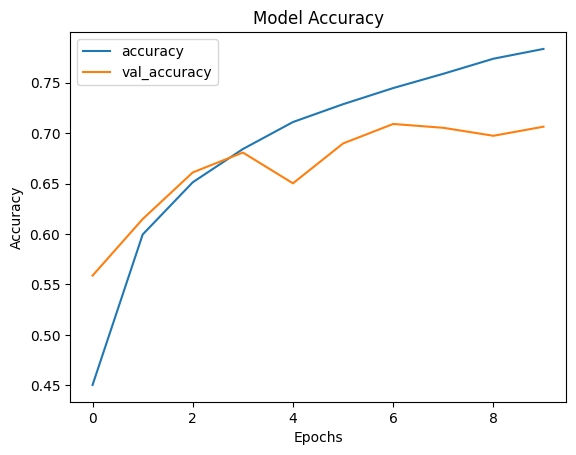

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.show()